# Dataset & Problem
Trough Machine Learning I hope to answer the following questions about the titanic:
1. Using passenger data from the titanic can you predict whether or not someone survived? 
2. What features impacted someone's survival the most?

This problem matters because it helps us understand the groups of people who were more likely to survive. The model could also be used if a specific person's survival was unknown.

The dataset includes the following features: 
- survival - wheter or not someone survived (0 = No, 1 = Yes)
- pclass - Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- sex	- sex
- Age - age in years	
- sibsp - # of siblings / spouses aboard the Titanic	
- parch - # of parents / children aboard the Titanic	
- ticket - Ticket number	
- fare - Passenger fare	
- cabin - Cabin number	
- embarked - Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

Variable Notes
- pclass: A proxy for socio-economic status (SES)
- age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5
- sibsp: The dataset defines family relations in this way...
    * Sibling = brother, sister, stepbrother, stepsister
    * Spouse = husband, wife (mistresses and fiancés were ignored)

- parch: The dataset defines family relations in this way...
    * Parent = mother, father
    * Child = daughter, son, stepdaughter, stepson
    * Some children travelled only with a nanny, therefore parch=0 for them.

# Data Preprocessing & Assumptions

In [788]:
# Import Packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

### Load Data

In [789]:
# Load the data
df = pd.read_csv("titanic.csv")

### Understanding the Dataset

In [790]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [791]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [792]:
df.shape

(891, 12)

In [793]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [794]:
# Veiw the number of each value in each column
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

PassengerId:
 PassengerId
1      1
599    1
588    1
589    1
590    1
      ..
301    1
302    1
303    1
304    1
891    1
Name: count, Length: 891, dtype: int64

Survived:
 Survived
0    549
1    342
Name: count, dtype: int64

Pclass:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Name:
 Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64

Sex:
 Sex
male      577
female    314
Name: count, dtype: int64

Age:
 Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
       

### Data Cleaning

In [795]:
# Delete duplcate rows
df = df.drop_duplicates()
print("Duplicate rows: " + str(df.duplicated().sum()))

Duplicate rows: 0


In [796]:
# Remove columns that are not useful for the model
df = df.drop(columns = ["PassengerId", "Name", "Ticket", "Cabin"])

In [797]:
# Check for null values
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [798]:
# Set missing age values to the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

In [799]:
# For rows where embarked is null, input the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [800]:
# One hot encoding on Sex and Embarked columns
df = pd.get_dummies(df, columns=["Sex"], drop_first=True)
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [801]:
# Create a new column for family size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [802]:
# Ensure preprocessing steps were successful
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,FamilySize
0,0,3,22.0,1,0,7.2500,True,False,True,2
1,1,1,38.0,1,0,71.2833,False,False,False,2
2,1,3,26.0,0,0,7.9250,False,False,True,1
3,1,1,35.0,1,0,53.1000,False,False,True,2
4,0,3,35.0,0,0,8.0500,True,False,True,1


### Exploratory Data Analysis

Survived
0    549
1    342
Name: count, dtype: int64


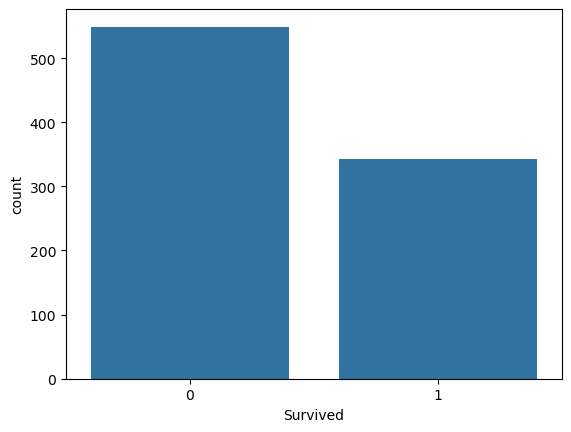

In [803]:
# Visualize the distribution of the target variable
sns.countplot(x = "Survived", data = df)
print(df["Survived"].value_counts())

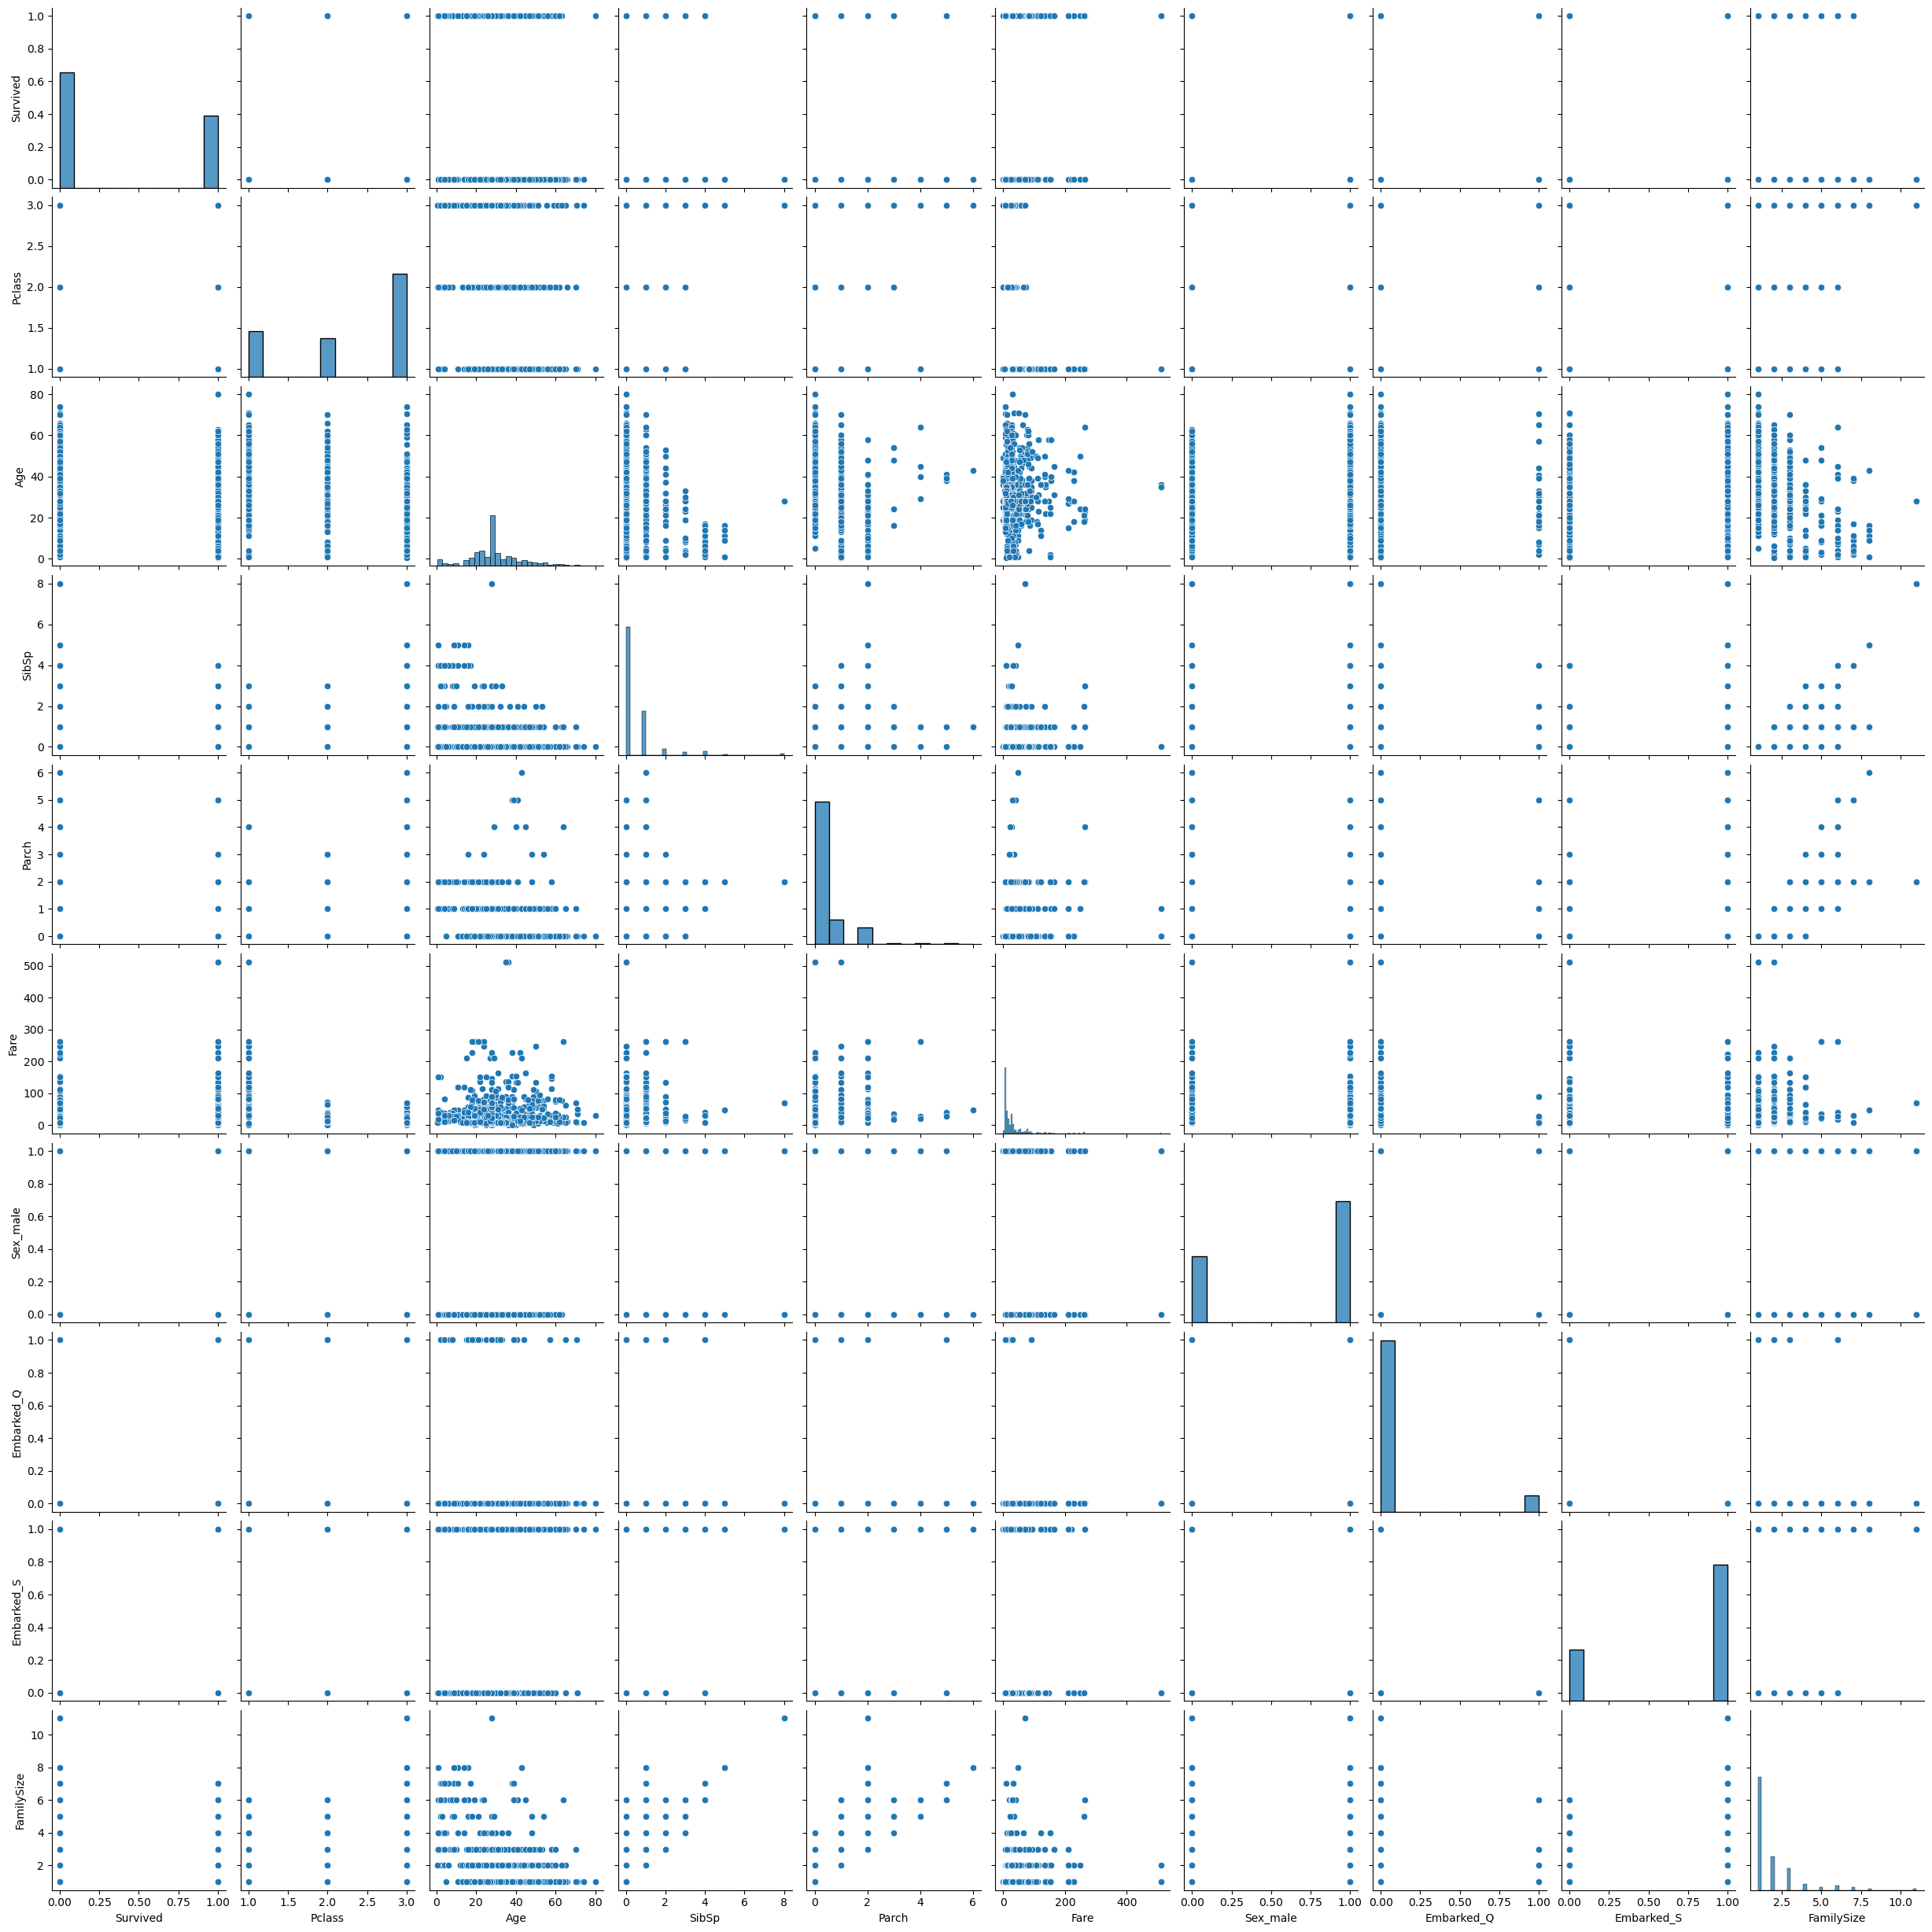

In [804]:
# Pairplot to visualize the relationships between features
sns.pairplot(data = df)

<Axes: >

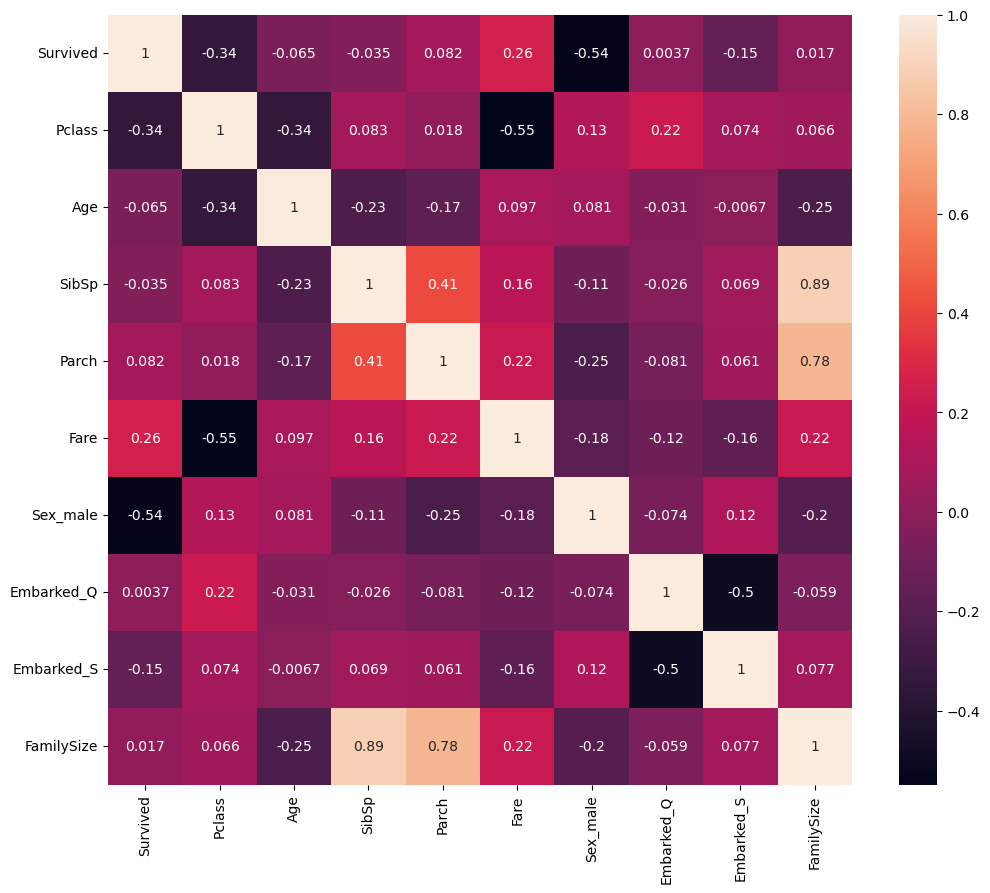

In [805]:
# Correlation matrix to visualize the relationships between features
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True)

# Model Experiments

In [806]:
# Seperate the target variable from the features
X = df.drop(columns = ["Survived"])
y = df["Survived"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=67)
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (712, 9)
X_test (179, 9)
y_train (712,)
y_test (179,)


### Model 1: Simple Decision Tree

In [807]:
# Create a decision tree classifier
model1 = DecisionTreeClassifier(random_state=67)
model1 = model1.fit(X_train, y_train) #fit the model to the training data

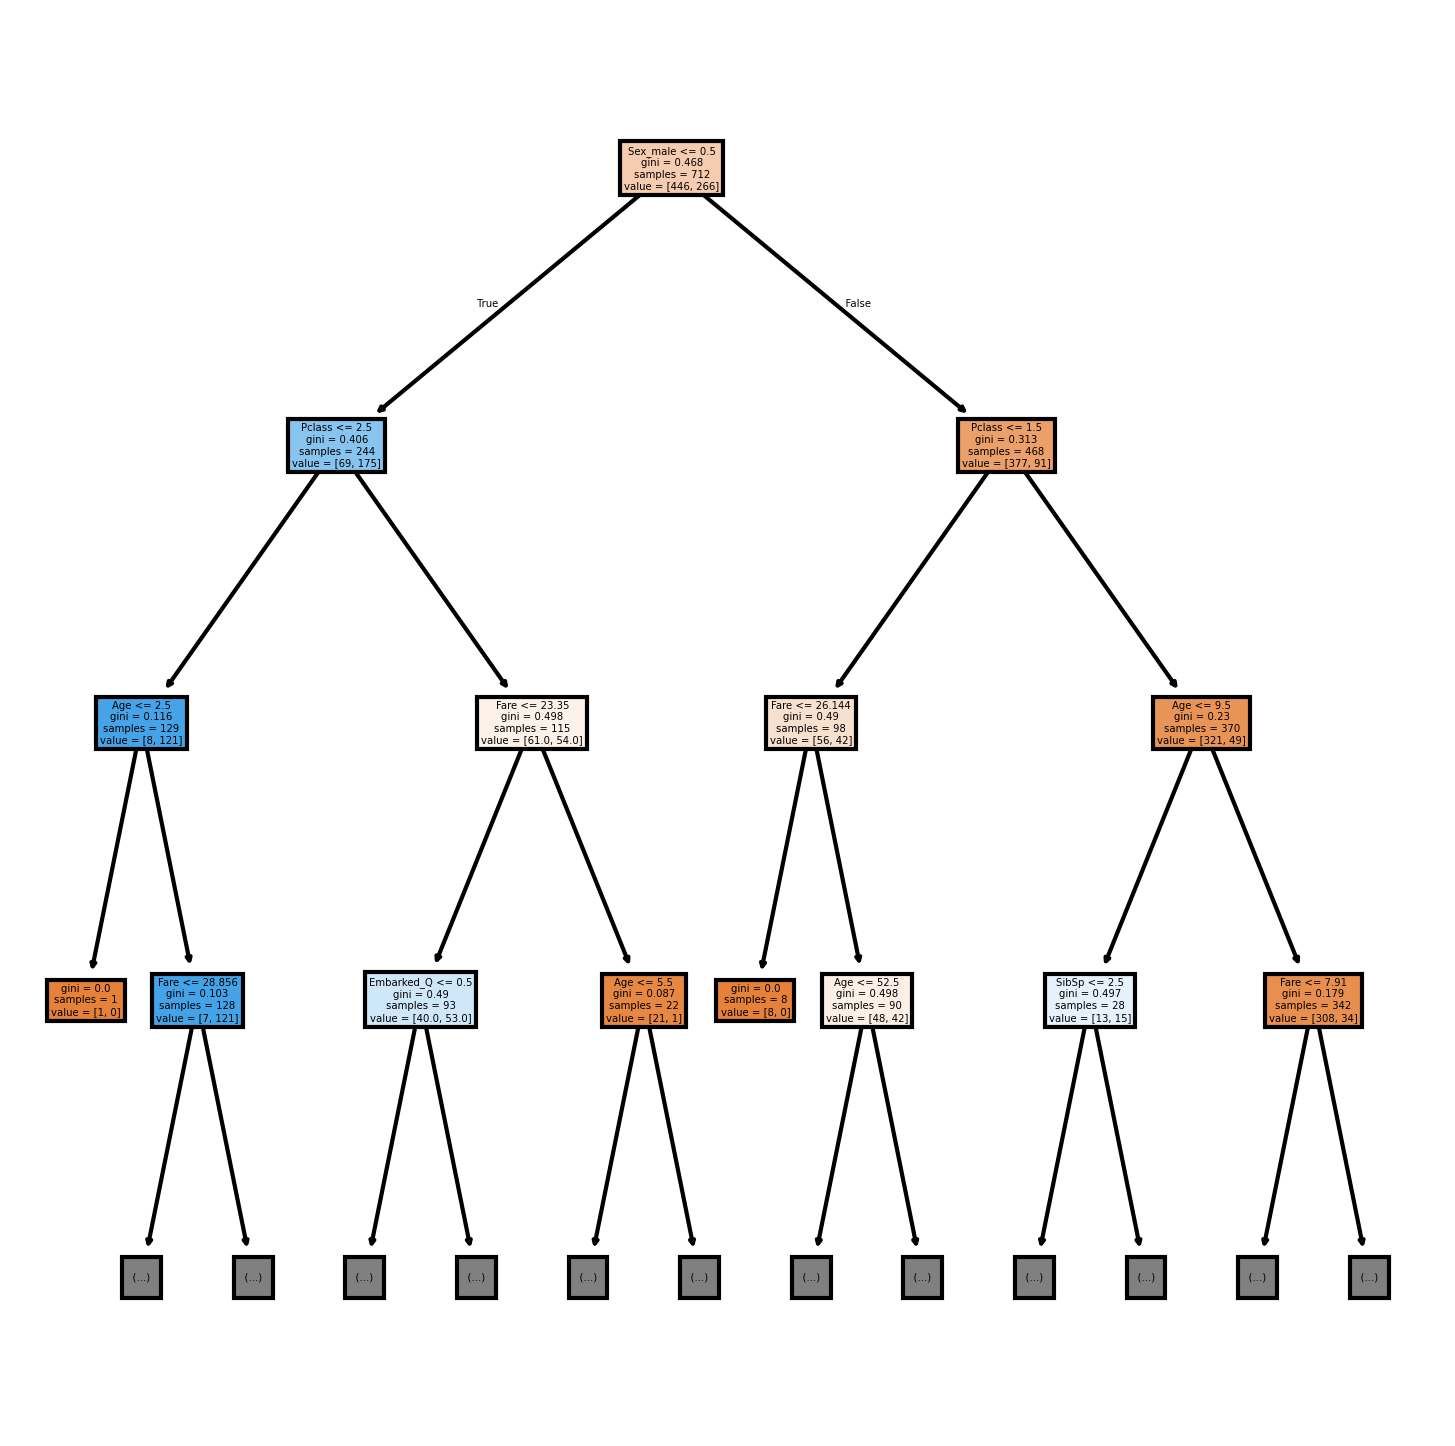

In [808]:
# Veiw the decision tree
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (6,6), dpi=300)
tree.plot_tree(model1, max_depth = 3, feature_names = X.columns, filled=True)
plt.show()

/var/folders/gg/ygm3cw754d38t0620ldb3nhh0000gn/T/ipykernel_85620/4208602844.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


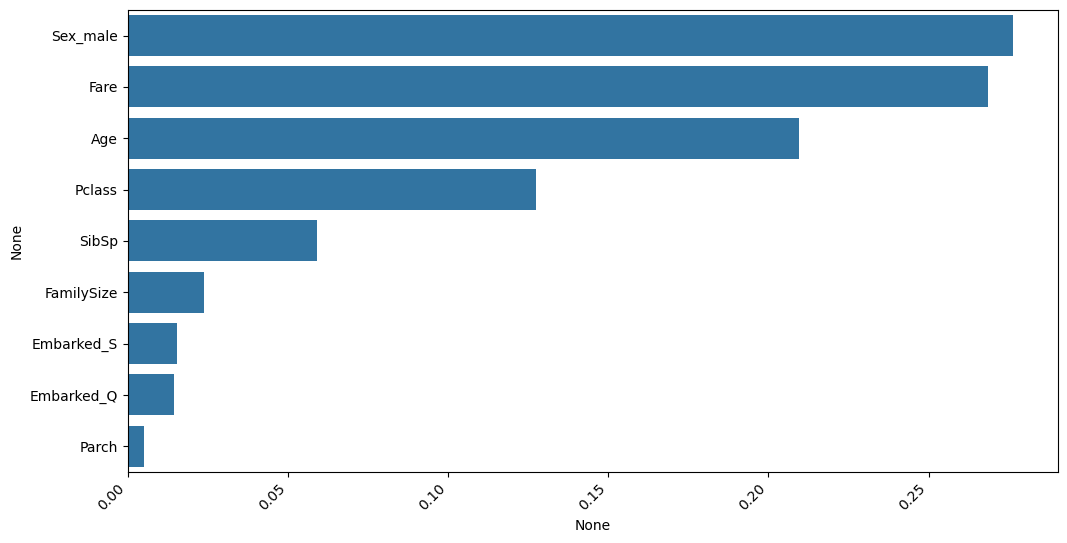

In [809]:
# Feature importance plot
fi = model1.feature_importances_ #feature importance array
fi = pd.Series(data = fi, index = X.columns) #convert to Pandas series for plotting
fi.sort_values(ascending=False, inplace=True) #sort descending

#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

In [810]:
model1.score(X_test, y_test)

0.7374301675977654

#### Model 1 Evaulation

In [811]:
y_pred = model1.predict(X_test)
print("True Negatives (TN):", ((y_test == 0) & (y_pred == 0)).sum())
print("False Positives (FP):", ((y_test == 0) & (y_pred == 1)).sum())
print("False Negatives (FN):", ((y_test == 1) & (y_pred == 0)).sum())
print("True Positives (TP):", ((y_test == 1) & (y_pred == 1)).sum())
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

True Negatives (TN): 84
False Positives (FP): 19
False Negatives (FN): 28
True Positives (TP): 48
Precision: 0.7164179104477612
Recall: 0.631578947368421
F1 Score: 0.6713286713286714


### Model 2: Decision Tree with Experimentation & Hyperparameter Tuning

In [812]:
depths = [1, 2, 3, 4, 5, None]
criterion = ["gini", "entropy"]
splitters = ["best", "random"]
min_samples_splits = [2, 3, 4, 5, 6, 7, 8, 9, 10]
min_samples_leafs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
best_score = 0
best_params = None
for depth in depths:
    for criterions in criterion:
        for splitter in splitters:
            for min_samples_split in min_samples_splits:
                for min_samples_leaf in min_samples_leafs:
                    model = DecisionTreeClassifier(max_depth = depth, criterion = criterions, splitter = splitter, min_samples_split = min_samples_split, min_samples_leaf = min_samples_leaf)
                    scores =  cross_val_score(model, X_train, y_train, cv = 5, scoring = "f1")
                    
                    # Veiw all outputs for each combination of parameters
                    # print(f"Max depth: {depth}, Criterion: {criterions}, Splitter: {splitter}, Min samples split: {min_samples_split}, Min samples leaf: {min_samples_leaf}, Average f1: {scores.mean()}:.4f")
                    if scores.mean() > best_score:
                        best_score = scores.mean()
                        best_params = (depth, criterions, splitter, min_samples_split, min_samples_leaf)

print(f"Best params: Max depth: {best_params[0]}, Criterion: {best_params[1]}, Splitter: {best_params[2]}, Min samples split: {best_params[3]}, Min samples leaf: {best_params[4]}, Best f1 score: {best_score:.4f}")

Best params: Max depth: None, Criterion: entropy, Splitter: random, Min samples split: 4, Min samples leaf: 3, Best f1 score: 0.7459


In [813]:
# Train a new model with the best parameters
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 67)
model2 = DecisionTreeClassifier(max_depth = best_params[0], criterion = best_params[1], splitter = best_params[2], min_samples_split = best_params[3], min_samples_leaf = best_params[4])
model2 = model2.fit(X_train, y_train)

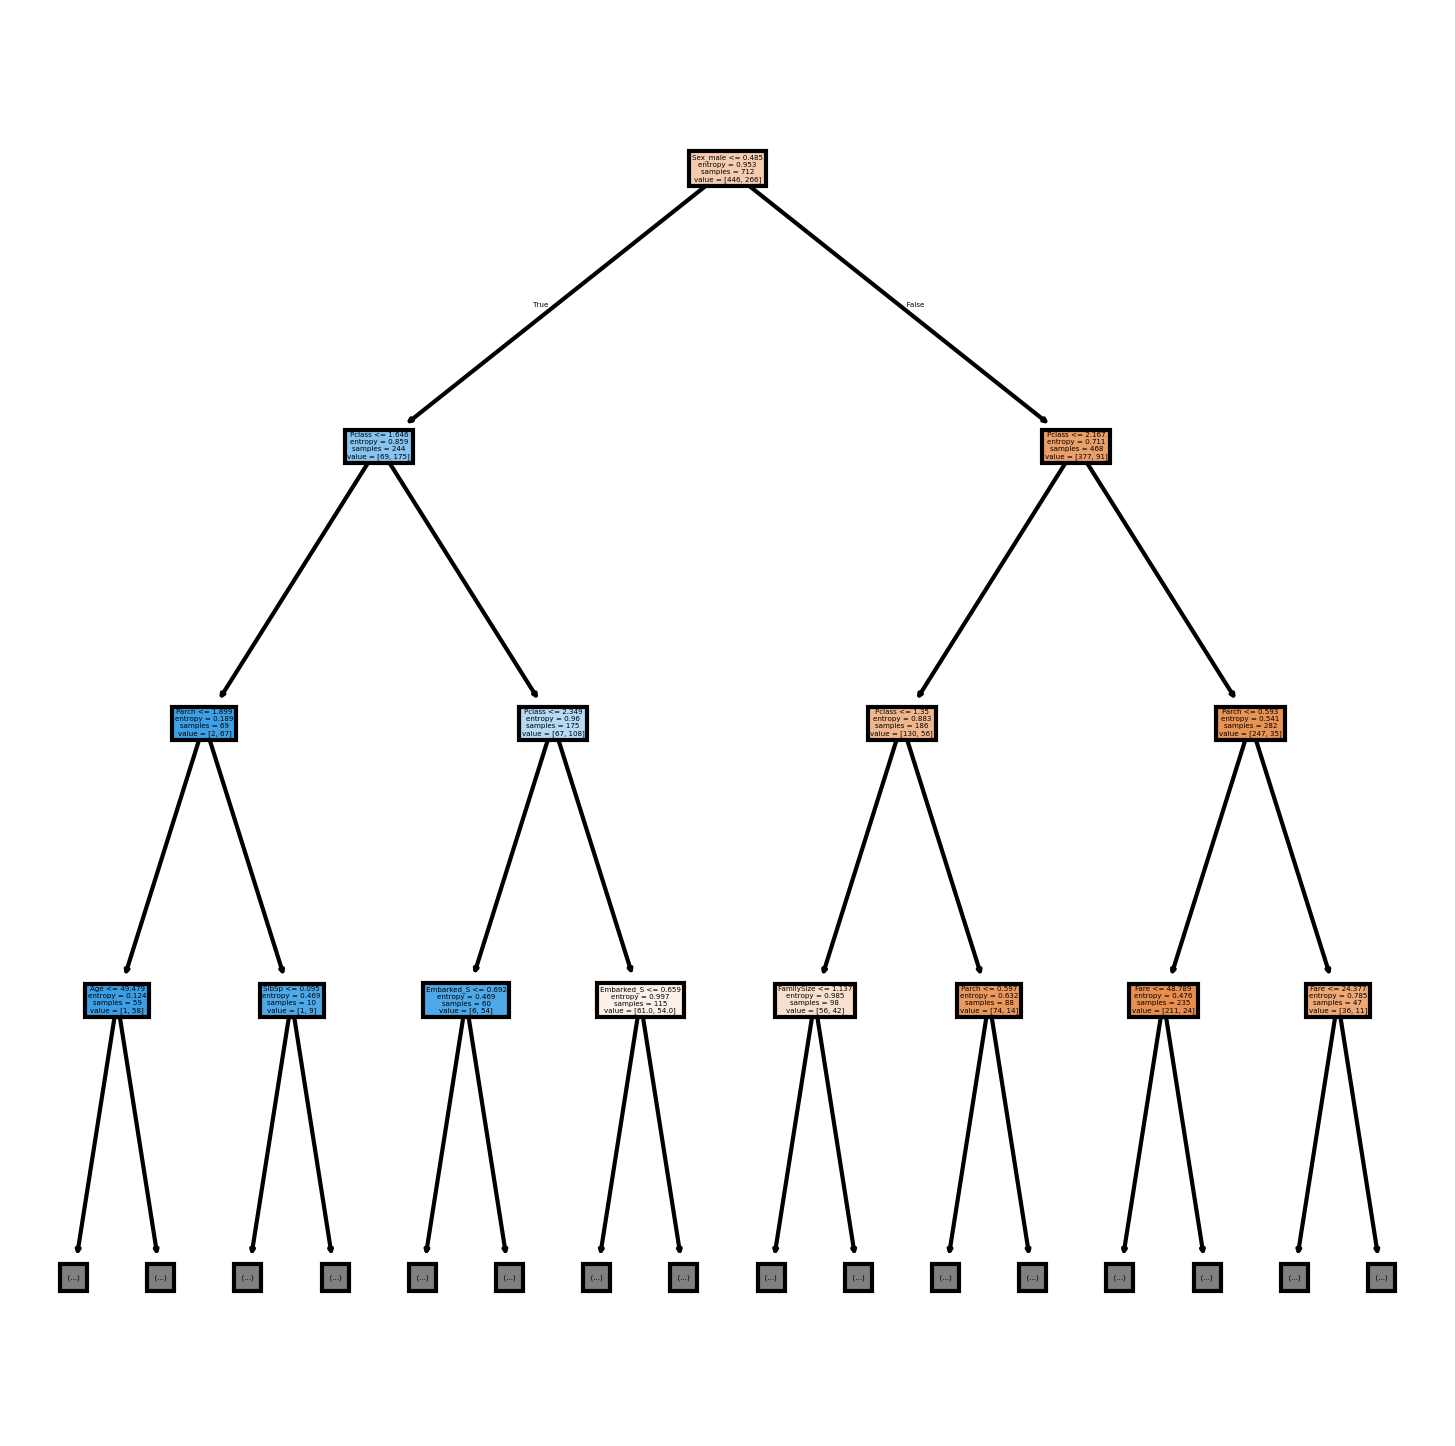

In [814]:
# Veiw the decision tree
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (6,6), dpi=300)
tree.plot_tree(model2, max_depth = 3, feature_names = X.columns, filled=True)
plt.show()

/var/folders/gg/ygm3cw754d38t0620ldb3nhh0000gn/T/ipykernel_85620/991385759.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


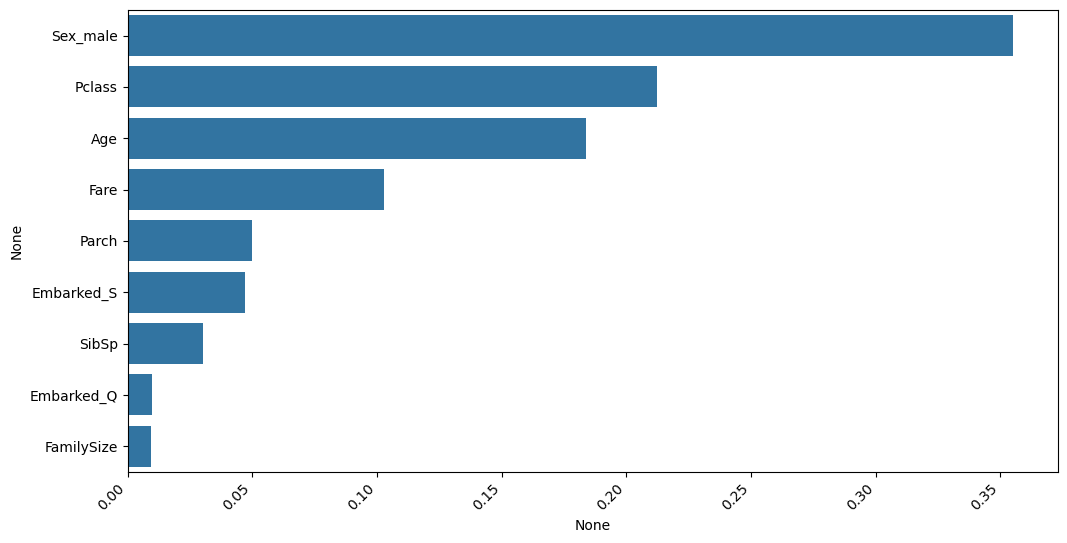

In [815]:
# Feature importance plot
fi = model2.feature_importances_ #feature importance array
fi = pd.Series(data = fi, index = X.columns) #convert to Pandas series for plotting
fi.sort_values(ascending=False, inplace=True) #sort descending

#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

In [816]:
model2.score(X_test, y_test)

0.8044692737430168

#### Model 2 Evaluation

In [817]:
y_pred = model2.predict(X_test)
print("True Negatives (TN):", ((y_test == 0) & (y_pred == 0)).sum())
print("False Positives (FP):", ((y_test == 0) & (y_pred == 1)).sum())
print("False Negatives (FN):", ((y_test == 1) & (y_pred == 0)).sum())
print("True Positives (TP):", ((y_test == 1) & (y_pred == 1)).sum())
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

True Negatives (TN): 89
False Positives (FP): 14
False Negatives (FN): 21
True Positives (TP): 55
Precision: 0.7971014492753623
Recall: 0.7236842105263158
F1 Score: 0.7586206896551724


### Model 3: Logistic Regression

In [818]:
# Train a logistic regression model
model3 = LogisticRegression(max_iter=10000, random_state=67)
model3 = model3.fit(X_train, y_train)
model3.score(X_test, y_test)

0.7988826815642458

#### Model 3 Evaluation

In [819]:
y_pred = model3.predict(X_test)
print("True Negatives (TN):", ((y_test == 0) & (y_pred == 0)).sum())
print("False Positives (FP):", ((y_test == 0) & (y_pred == 1)).sum())
print("False Negatives (FN):", ((y_test == 1) & (y_pred == 0)).sum())
print("True Positives (TP):", ((y_test == 1) & (y_pred == 1)).sum())
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

True Negatives (TN): 87
False Positives (FP): 16
False Negatives (FN): 20
True Positives (TP): 56
Precision: 0.7777777777777778
Recall: 0.7368421052631579
F1 Score: 0.7567567567567568


# References & AI Transparency
Portions of code were copied (and then edited) from previous in-class studio notes/assignments. Additionally, GitHub Copilot was occasionally used to write code with its Inline Suggestions feature.

Dataset: https://www.kaggle.com/competitions/titanic/

Logistic Regression Guide: https://www.w3schools.com/python/python_ml_logistic_regression.asp